## 定义模型

In [1]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv
load_dotenv()

provider = "modelscope"  # 可选 "modelscope", "dashscope" "openrouter"
model = "MiniMax/MiniMax-M2.5"

if provider == "modelscope":
    model = model if model else os.getenv("MODELSCOPE_MODEL")
    base_url = os.getenv("MODELSCOPE_BASE_URL")
    api_key = os.getenv("MODELSCOPE_API_KEY")
elif provider == "dashscope":
    model = model if model else os.getenv("DASHSCOPE_MODEL")
    base_url = os.getenv("DASHSCOPE_BASE_URL")
    api_key = os.getenv("DASHSCOPE_API_KEY")
elif provider == "openrouter":
    model = model if model else os.getenv("OPENROUTER_MODEL")
    base_url = os.getenv("OPENROUTER_BASE_URL")
    api_key = os.getenv("OPENROUTER_API_KEY")
print(f"Using model [{model}] from provider [{provider}]")

llm = init_chat_model(
    model=model,
    model_provider="openai",
    base_url=base_url,
    api_key=api_key,
)

Using model [MiniMax/MiniMax-M2.5] from provider [modelscope]


## 定义节点

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"写一个关于{state['topic']}的笑话，不超过50字")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"写一个关于{state['topic']}的故事，不超过50字")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"写一首关于{state['topic']}的诗，不超过50字")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

## 创建图

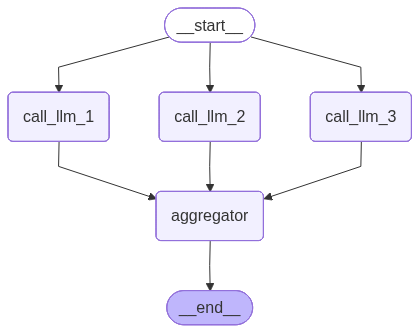

In [3]:
# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

## 运行

In [4]:
# Invoke
state = parallel_workflow.invoke({"topic": "新年"})
print(state["combined_output"])

Here's a story, joke, and poem about 新年!

STORY:
小杰等到午夜钟声，跑上楼顶，和妹妹一起放飞孔明灯，灯光缓缓升空，映照出新年的希望。

JOKE:
新年我把“减肥”改成“增肥”，结果体重依旧向前——因为美食还在。

POEM:
春风送暖入屠苏，  
鞭炮声里一岁除。  
梅花映雪红如火，  
万家灯彩庆新福。
